In [14]:
import gpxpy
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import uuid
from pathlib import Path
from typing import Optional, List, Dict

In [4]:
# CONFIG

PISTES_FP = "/home/tpogier/Projects/powpal/data/raw/pistes/vicheres_pistes.geojson"
TRACK_POINTS_FP = "/home/tpogier/Projects/powpal/data/raw/tracks/Slopes_A_day_snowboarding_at_Vichères_Liddes.gpx"

In [8]:
# READ IN DATA

pistes_gdf = gpd.read_file(PISTES_FP)
track_points_gdf = gpd.read_file(TRACK_POINTS_FP, layer="track_points")

In [16]:
user_id = 'theo'
activity_id = '1234'

rows: List[Dict] = []

with open(TRACK_POINTS_FP, "r", encoding="utf-8") as f:
    gpx = gpxpy.parse(f)

for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:

            rows.append(
                {
                    "user_id": user_id,
                    "activity_id": activity_id,
                    "timestamp": point.time,
                    "lat": point.latitude,
                    "lon": point.longitude,
                    "elevation_m": point.elevation,
                    "source_file": TRACK_POINTS_FP.name,
                }
            )

df = pd.DataFrame(rows)

AttributeError: 'str' object has no attribute 'name'

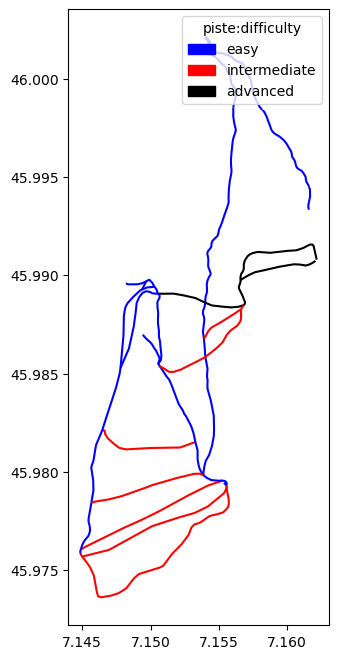

In [27]:
# VIEW DATA

# 1. Define your category -> color mapping
color_map = {
    "easy": "blue",
    "intermediate": "red",
    "advanced": "black"
}

col = "piste:difficulty"

# 2. Create a color column (fallback color for unknown categories)
pistes_gdf["plot_color"] = pistes_gdf[col].map(color_map).fillna("#bdbdbd")

# 3. Plot using those explicit colors
ax = pistes_gdf.plot(color=pistes_gdf["plot_color"], figsize=(10, 8))

# 4. Optional legend
present = [c for c in color_map if c in pistes_gdf[col].dropna().unique()]
handles = [mpatches.Patch(color=color_map[c], label=c) for c in present]
if pistes_gdf[col].isna().any() or (~pistes_gdf[col].isin(color_map)).any():
    handles.append(mpatches.Patch(color="#bdbdbd", label="other/unknown"))

ax.legend(handles=handles, title=col, loc="best")
plt.show()

# 2. Create a color column (fallback color for unknown categories)
pistes_gdf["plot_color"] = pistes_gdf[col].map(color_map).fillna("#bdbdbd")


In [28]:
# JOINING DATASETS

# Ensure both are in the same CRS
if track_points_gdf.crs != pistes_gdf.crs:
    pistes_gdf = pistes_gdf.to_crs(track_points_gdf.crs)

# For meaningful distance values, use a projected CRS (meters), not lat/lon
if track_points_gdf.crs.is_geographic:
    # pick a suitable local projected CRS for your area if you know it
    track_points_gdf = track_points_gdf.to_crs(2056)
    pistes_gdf = pistes_gdf.to_crs(2056)

# Nearest join: each track point gets attributes of nearest piste
points_with_nearest_piste = gpd.sjoin_nearest(
    track_points_gdf,
    pistes_gdf,
    how="left",
    distance_col="distance_to_piste_m"
)

points_with_nearest_piste.head()


,track_fid,track_seg_id,track_seg_point_id,ele,time,magvar,geoidheight,name_left,cmt,desc,...,highway,name_right,piste:difficulty,piste:grooming,piste:name,piste:type,source,tracktype,plot_color,distance_to_piste_m
0,0,0,0,2048.5,2026-02-26 10:09:45+00:00,NaN,NaN,None,None,None,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade5,blue,1.489930
1,0,0,1,2047.6,2026-02-26 10:09:52+00:00,NaN,NaN,None,None,None,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade5,blue,2.197656
2,0,0,2,2046.7,2026-02-26 10:12:12+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,1.422556
3,0,0,3,2045.5,2026-02-26 10:12:16+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,0.139434
4,0,0,4,2044.2,2026-02-26 10:12:19+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,0.541319


<Axes: >

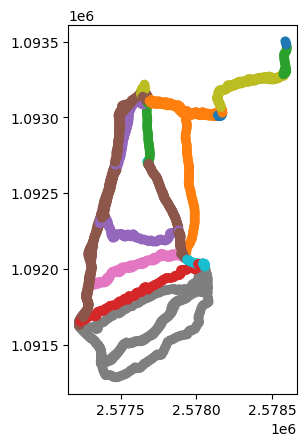

In [29]:
points_with_nearest_piste.plot(
    column='id'
)

In [30]:
points_with_nearest_piste.to_file('data/processed/track_points_with_nearest_piste.geojson')

# How to divide the points into runs

1. Sort points by time (and by skier/activity if you have multiple tracks).
2. Define a “new run” when time gap to previous point is bigger than a threshold (e.g., 2–5 minutes).
3. Also force a new run when matched piste changes.
4. Cumulatively number these breaks to get run_id.

Core functions: sort_values, groupby, diff, boolean conditions, cumsum.

In [31]:
points_with_nearest_piste.head()

,track_fid,track_seg_id,track_seg_point_id,ele,time,magvar,geoidheight,name_left,cmt,desc,...,highway,name_right,piste:difficulty,piste:grooming,piste:name,piste:type,source,tracktype,plot_color,distance_to_piste_m
0,0,0,0,2048.5,2026-02-26 10:09:45+00:00,NaN,NaN,None,None,None,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade5,blue,1.489930
1,0,0,1,2047.6,2026-02-26 10:09:52+00:00,NaN,NaN,None,None,None,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade5,blue,2.197656
2,0,0,2,2046.7,2026-02-26 10:12:12+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,1.422556
3,0,0,3,2045.5,2026-02-26 10:12:16+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,0.139434
4,0,0,4,2044.2,2026-02-26 10:12:19+00:00,NaN,NaN,None,None,None,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,0.541319


In [32]:
import pandas as pd

df = points_with_nearest_piste.copy()

# columns to adapt:
time_col = "time"
piste_col = "id"          # or "index_right" if that's your piste key after sjoin_nearest
track_col = "track_seg_id"          # optional; use if multiple tracks exist

# 1) ensure datetime + sort
df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
sort_cols = [track_col, time_col] if track_col in df.columns else [time_col]
df = df.sort_values(sort_cols).reset_index(drop=True)

# 2) grouping scope (per track if available)
grp = [track_col] if track_col in df.columns else []

# 3) time gap (seconds)
df["dt_sec"] = df.groupby(grp)[time_col].diff().dt.total_seconds()

# 4) piste change
prev_piste = df.groupby(grp)[piste_col].shift()
piste_changed = df[piste_col] != prev_piste

# 5) new run condition
gap_sec = 180  # 3 minutes; tune this
new_run = df["dt_sec"].isna() | (df["dt_sec"] > gap_sec) | piste_changed

# 6) run numbering
df["run_num"] = new_run.groupby(df[grp].apply(tuple, axis=1) if grp else 0).cumsum()

# optional readable run_id
if track_col in df.columns:
    df["run_id"] = df[track_col].astype(str) + "_" + df["run_num"].astype(str)
else:
    df["run_id"] = df["run_num"].astype(str)


In [33]:
df.to_file('data/processed/run_split_tracks.geojson')

Looks good!

Now it needs to be cleaned up, there are quite a few 'runs' which clearly aren't runs - chilling at the cafe, waiting at the top of the lift etc.

First I'll get a distribution of run lengths - times, distances, elevation changes...

In [34]:
df.columns

Index(['track_fid', 'track_seg_id', 'track_seg_point_id', 'ele', 'time',
       'magvar', 'geoidheight', 'name_left', 'cmt', 'desc', 'src',
       'link1_href', 'link1_text', 'link1_type', 'link2_href', 'link2_text',
       'link2_type', 'sym', 'type', 'fix', 'sat', 'hdop', 'vdop', 'pdop',
       'ageofdgpsdata', 'dgpsid', 'geometry', 'index_right', 'id', '@id',
       'highway', 'name_right', 'piste:difficulty', 'piste:grooming',
       'piste:name', 'piste:type', 'source', 'tracktype', 'plot_color',
       'distance_to_piste_m', 'dt_sec', 'run_num', 'run_id'],
      dtype='str')

In [36]:
import geopandas as gpd
import pandas as pd

# --- columns to adapt ---
run_col = "run_id"
time_col = "time"
elev_col = "ele"
piste_id_col = "id"   # must exist in df + pistes_gdf

# 1) prep
df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.sort_values([run_col, time_col]).copy()

# 2) distance per run (sum of point-to-point segment lengths)
if df.crs.is_geographic:
    df = df.to_crs(3857)  # ideally use your local projected CRS

prev_geom = df.groupby(run_col).geometry.shift()
df["segment_m"] = df.geometry.distance(prev_geom).fillna(0)

# 3) aggregate run stats (include piste_id)
run_stats = (
    df.groupby(run_col)
      .agg(
          piste_id=(piste_id_col, "first"),
          start_time=(time_col, "min"),
          end_time=(time_col, "max"),
          distance_m=("segment_m", "sum"),
          elev_start=(elev_col, "first"),
          elev_end=(elev_col, "last"),
          elev_min=(elev_col, "min"),
          elev_max=(elev_col, "max"),
          n_points=("geometry", "size"),
      )
      .reset_index()
)

run_stats["duration_s"] = (run_stats["end_time"] - run_stats["start_time"]).dt.total_seconds()
run_stats["duration_min"] = run_stats["duration_s"] / 60
run_stats["distance_km"] = run_stats["distance_m"] / 1000
run_stats["elev_change_m"] = run_stats["elev_end"] - run_stats["elev_start"]
run_stats["elev_range_m"] = run_stats["elev_max"] - run_stats["elev_min"]

# 4) attach piste geometry and make GeoDataFrame
run_stats = run_stats.merge(pistes_gdf, left_on="piste_id", right_on=piste_id_col, how="left").drop(columns=[piste_id_col])

run_stats = gpd.GeoDataFrame(run_stats, geometry="geometry", crs=pistes_gdf.crs)

run_stats.head()


,run_id,piste_id,start_time,end_time,distance_m,elev_start,elev_end,elev_min,elev_max,n_points,...,highway,name,piste:difficulty,piste:grooming,piste:name,piste:type,source,tracktype,geometry,plot_color
0,0_1,way/982183331,2026-02-26 10:09:45+00:00,2026-02-26 10:09:52+00:00,10.848435,2048.5,2047.6,2047.6,2048.5,2,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade5,"LINESTRING (2577587.735 1092865.051, 2577598.0...",blue
1,0_10,way/52041333,2026-02-26 10:31:34+00:00,2026-02-26 10:32:18+00:00,39.492052,2026.9,2022.2,2022.2,2026.9,5,...,NaN,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,"LINESTRING (2577493.407 1093156.229, 2577504.6...",blue
2,0_100,way/52041160,2026-02-26 14:45:24+00:00,2026-02-26 14:46:53+00:00,470.825298,2049.4,2011.0,2011.0,2049.4,33,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade4,"LINESTRING (2577677.683 1092695.31, 2577683.10...",blue
3,0_101,way/52041159,2026-02-26 14:46:55+00:00,2026-02-26 14:46:55+00:00,0.000000,2010.0,2010.0,2010.0,2010.0,1,...,NaN,La Combette,intermediate,classic,NaN,downhill,GPS survey 2010.03.08,NaN,"LINESTRING (2577355.472 1092324.469, 2577364.2...",red
4,0_102,way/52041160,2026-02-26 14:46:57+00:00,2026-02-26 14:47:19+00:00,175.319352,2008.4,1987.3,1987.3,2008.4,12,...,track,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade4,"LINESTRING (2577677.683 1092695.31, 2577683.10...",blue


In [37]:
# Plotting

def plot_dists(df):

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(df["duration_min"], bins=60, kde=True, ax=axes[0][0])
    axes[0][0].set_title("Run Duration (min)")

    sns.histplot(df["distance_km"], bins=60, kde=True, ax=axes[0][1])
    axes[0][1].set_title("Run Distance (km)")

    sns.histplot(df["elev_change_m"], bins=60, kde=True, ax=axes[1][0])
    axes[1][0].set_title("Run Elevation Change (m)")

    sns.histplot(df["n_points"], bins=60, kde=True, ax=axes[1][1])
    axes[1][1].set_title("Number of Points")

    plt.tight_layout()
    plt.show()

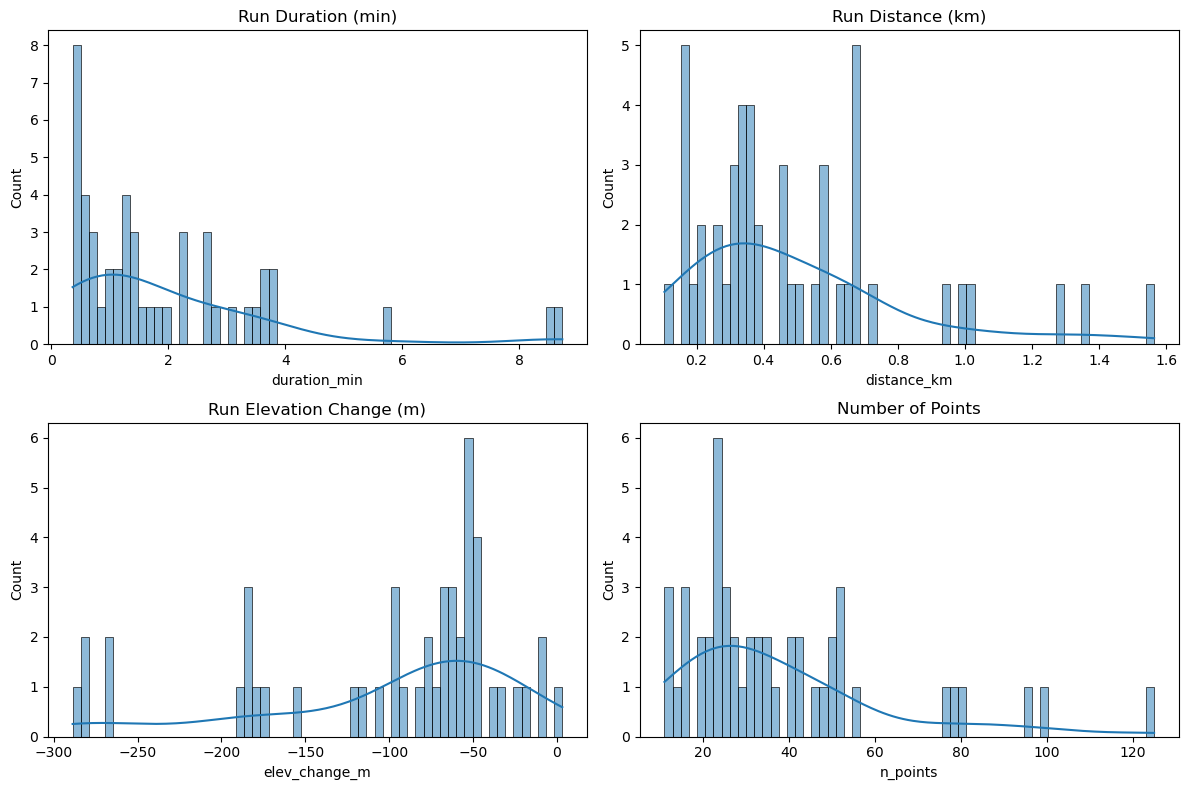

In [38]:
plot_dists(run_stats[run_stats['n_points']>10])

In [39]:
# Removing points from runs that are less than 10

run_stats_cleaned = run_stats[(run_stats['n_points']>10) & (run_stats['elev_change_m']<-25)]

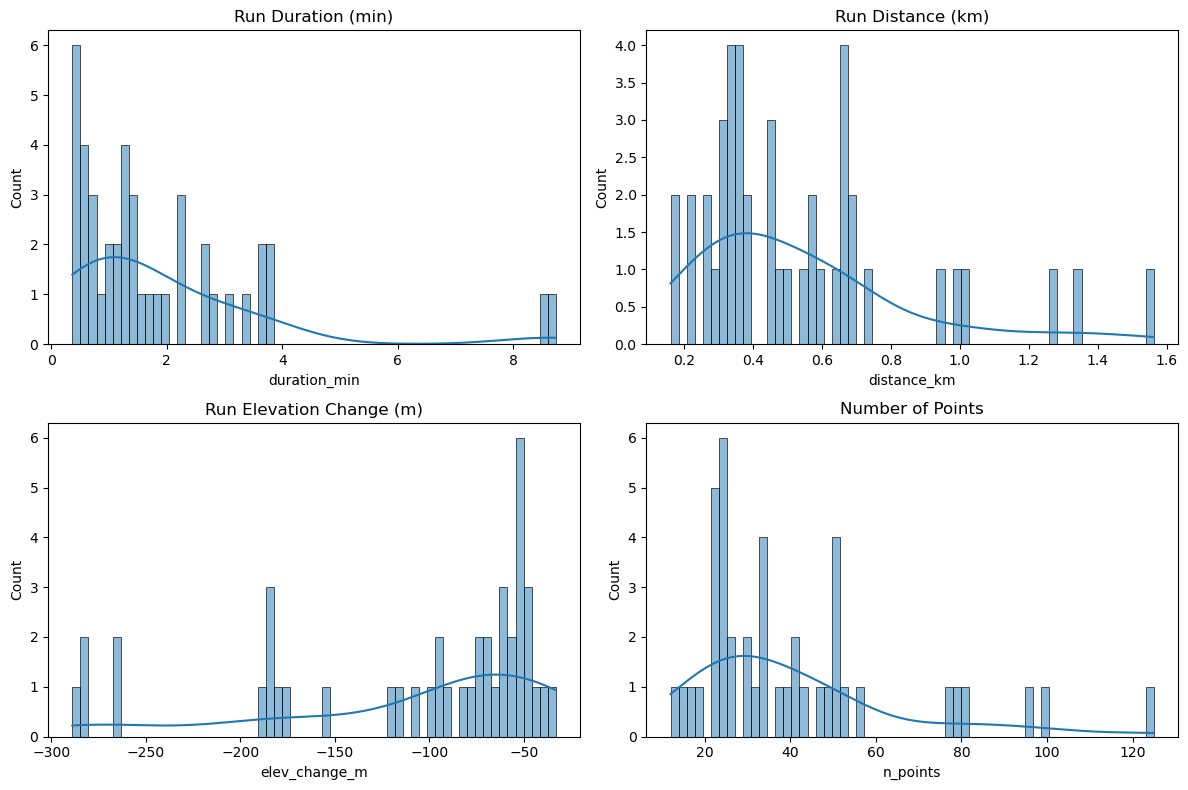

In [40]:
plot_dists(run_stats_cleaned)

In [41]:
# removing non runs from points

# points df with all points
# e.g. points_with_nearest_piste
points_df = df.copy()

# runs df that already contains only valid runs
# e.g. valid_runs_df
valid_runs_df = run_stats_cleaned.copy()
# both must share the same run id column:
run_id_col = "run_id"

# keep only points whose run_id is in valid_runs_df
valid_ids = set(valid_runs_df[run_id_col].dropna().unique())
points_runs_only = points_df[points_df[run_id_col].isin(valid_ids)].copy()

# optional: reset index
points_runs_only = points_runs_only.reset_index(drop=True)

print(f"Kept {len(points_runs_only):,} points from {len(valid_ids):,} runs \nRemoved {(len(run_stats) - len(valid_ids)):,}")


Kept 1,763 points from 43 runs 
Removed 99


In [42]:
points_runs_only.to_file("data/processed/track_points_valid_runs_only.geojson")

In [43]:
run_stats_cleaned.to_file("data/processed/run_stats_valid_runs.geojson")